# Model Training

## 1. Import Data and Required Packages

In [12]:
# basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [13]:
df = pd.read_csv('data/stud.csv')

In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Preparing X and Y variables

In [15]:
x = df.drop(columns="math_score")
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [16]:
y = df["math_score"]
y[:5]

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [17]:
numeric_features = [feature for feature in x.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in x.columns if df[feature].dtype == 'str']

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, categorical_features),
        ("StandardScaler", numeric_transformer, numeric_features)
    ]
)

In [7]:
x = preprocessor.fit_transform(x)

In [8]:
x.shape

(1000, 19)

In [9]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

x_train.shape, x_test.shape

((800, 19), (200, 19))

## 3. Create an Evaluate Function to give all metrics after model training

In [10]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [11]:
models = {
    "linear_regression": LinearRegression(),
    "lasso": Lasso(),
    "ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "decision_tree": DecisionTreeRegressor(),
    "random_forest_regressor": RandomForestRegressor(),
    "xgb_regressor": XGBRegressor(),
    "catboosting_regressor": CatBoostRegressor(verbose=False),
    "adaboost_regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for key, value in models.items():
    model = models[key]
    model.fit(x_train, y_train)

    # make_predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # evaluate_train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)


    print('='*45)
    print(f"---------- {key} ----------")
    model_list.append(key)

    print("Model performance for training set")
    print(f"Root mean squared error: {model_train_rmse}")
    print(f"Mean absolute error: {model_train_mae}")
    print(f"R2 Score: {model_train_r2}")

    print("-----------------------------")

    print("Model performance for test set")

    print(f"Root mean squared error: {model_test_rmse}")
    print(f"Mean absolute error: {model_test_mae}")
    print(f"R2 Score: {model_test_r2}")

    r2_list.append(model_test_r2)
    

---------- linear_regression ----------
Model performance for training set
Root mean squared error: 5.323050852720513
Mean absolute error: 4.266711846071957
R2 Score: 0.8743172040139593
-----------------------------
Model performance for test set
Root mean squared error: 5.393993869732842
Mean absolute error: 4.21476314247485
R2 Score: 0.8804332983749565
---------- lasso ----------
Model performance for training set
Root mean squared error: 6.593815587795566
Mean absolute error: 5.206302661246528
R2 Score: 0.8071462015863456
-----------------------------
Model performance for test set
Root mean squared error: 6.519694535667421
Mean absolute error: 5.157881810347763
R2 Score: 0.8253197323627852
---------- ridge ----------
Model performance for training set
Root mean squared error: 5.323324922741654
Mean absolute error: 4.264987823725981
R2 Score: 0.8743042615212909
-----------------------------
Model performance for test set
Root mean squared error: 5.390387016935638
Mean absolute error

## 4. Results

In [13]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['model_name', 'r2_score']).sort_values(by=['r2_score'], ascending=False)

,model_name,r2_score
2,ridge,0.880593
0,linear_regression,0.880433
5,random_forest_regressor,0.860396
7,catboosting_regressor,0.851632
8,adaboost_regressor,0.845468
6,xgb_regressor,0.827797
1,lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,decision_tree,0.737937


## 5. Linear Regression

In [15]:
linear_model = LinearRegression(fit_intercept=True)
linear_model = linear_model.fit(x_train, y_train)
y_pred = linear_model.predict(x_test)
score = r2_score(y_test, y_pred)*100
print(f"Accuracy of the model is {score:.2f}%")

Accuracy of the model is 88.04%


## 6. Plot the Results

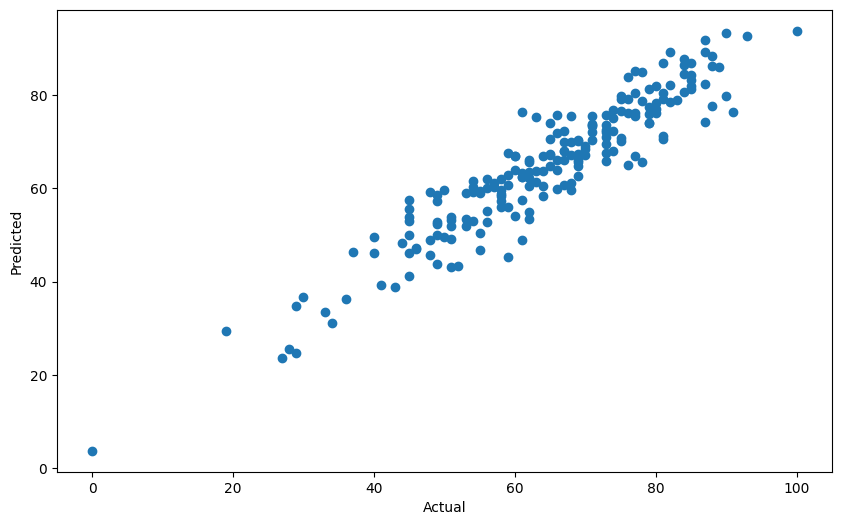

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

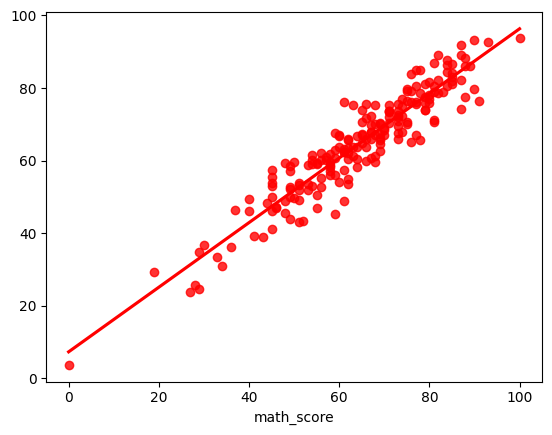

In [17]:
sns.regplot(x=y_test, y=y_pred, ci=None, color="red")

plt.show()

## 6.1. Difference between Actual and Predicted Values

In [18]:
pred_df = pd.DataFrame(
    {
        "actual_value": y_test,
        "predicted_value": y_pred,
        "difference": y_test - y_pred
    }
)

pred_df

,actual_value,predicted_value,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
